In [9]:
#Install packages
!pip install -q pennylane pandas matplotlib scikit-learn seaborn numpy tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 74.4 MB/s eta 0:00:00


In [1]:


# Import packages
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf

import pennylane as qml
import pennylane.numpy as qnp

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

print("TensorFlow version:", tf.__version__)
print("PennyLane version:", qml.__version__)

TensorFlow version: 2.19.0
PennyLane version: 0.44.1


In [2]:

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# dataset in Drive
data_read_path = os.path.join(
    "/content/drive", "MyDrive", "Colab Notebooks", "Datasets", "Phishing_Legitimate_full.csv"
)

#data_read_path = os.path.join(
 #   "drive", "MyDrive", "Colab Notebooks", "Datasets", "Phishing_Legitimate_full.csv"
#)
print("Dataset path:", data_read_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset path: /content/drive/MyDrive/Colab Notebooks/Datasets/Phishing_Legitimate_full.csv


In [3]:
import pandas as pd

# Correct path (IMPORTANT: starts with /content/)
data_read_path = "/content/drive/MyDrive/Colab Notebooks/Phishing_Legitimate_full.csv"

# Load dataset
phishing_data = pd.read_csv(data_read_path).dropna()

# Show data
display(phishing_data.sample(5))

# Info
phishing_data.info()

,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
1968,1969,2,1,3,60,0,0,0,0,0,...,0,0,0,1,0,1,1,1,1,1
1000,1001,2,0,2,51,0,0,0,0,0,...,0,0,0,1,1,-1,1,-1,1,1
7316,7317,2,1,3,89,3,0,0,0,0,...,0,0,0,1,-1,1,1,0,1,0
2200,2201,3,1,4,55,0,0,0,0,0,...,0,0,0,1,0,-1,1,-1,-1,1
9327,9328,2,1,6,47,0,0,0,0,0,...,1,0,0,1,1,0,1,1,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  10000 non-null  int64  
 1   NumDots                             10000 non-null  int64  
 2   SubdomainLevel                      10000 non-null  int64  
 3   PathLevel                           10000 non-null  int64  
 4   UrlLength                           10000 non-null  int64  
 5   NumDash                             10000 non-null  int64  
 6   NumDashInHostname                   10000 non-null  int64  
 7   AtSymbol                            10000 non-null  int64  
 8   TildeSymbol                         10000 non-null  int64  
 9   NumUnderscore                       10000 non-null  int64  
 10  NumPercent                          10000 non-null  int64  
 11  NumQueryComponents                  10000 


## **1.- Dataset Preprocessing **


In [14]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

# Separate features and label
phishing_X = phishing_data.drop(['id', 'CLASS_LABEL'], axis=1)
phishing_y = phishing_data['CLASS_LABEL']

# Select top 10 features via ANOVA F-value
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(phishing_X, phishing_y)

selected_idx = selector.get_support(indices=True)
selected_phishing_features = phishing_X.iloc[:, selected_idx]

print("Selected feature indices:", selected_idx)
display(selected_phishing_features.head())

# Classical Neural Network scaling
nn_scaler = StandardScaler()
nn_features_scaled = nn_scaler.fit_transform(selected_phishing_features)

nn_phishing_x_train, nn_phishing_x_test, nn_phishing_y_train, nn_phishing_y_test = train_test_split(
    nn_features_scaled,
    phishing_y,
    train_size=0.7,
    test_size=0.3,
    random_state=42,
    stratify=phishing_y,
)

# Quantum Neural Network scaling to [0, 2π]
qnn_scaler = MinMaxScaler(feature_range=(0, 2 * np.pi))
qnn_features_scaled = qnn_scaler.fit_transform(selected_phishing_features)

# Use first 6 features for QNN (6 qubits)
qnn_features_scaled_6 = qnn_features_scaled[:, :6]

qnn_phishing_x_train, qnn_phishing_x_test, qnn_phishing_y_train, qnn_phishing_y_test = train_test_split(
    qnn_features_scaled_6,
    phishing_y,
    train_size=0.7,
    test_size=0.3,
    random_state=42,
    stratify=phishing_y,
)

print("NN train shape:", nn_phishing_x_train.shape)
print("NN test shape:", nn_phishing_x_test.shape)
print("QNN train shape:", qnn_phishing_x_train.shape)
print("QNN test shape:", qnn_phishing_x_test.shape)

Selected feature indices: [ 0  4 24 26 29 33 34 38 39 47]


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [19] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,NumDots,NumDash,NumSensitiveWords,PctExtHyperlinks,InsecureForms,PctNullSelfRedirectHyperlinks,FrequentDomainNameMismatch,SubmitInfoToEmail,IframeOrFrame,PctExtNullSelfRedirectHyperlinksRT
0,3,0,0,0.000,1,0.0,0,0,0,1
1,3,0,1,0.000,1,0.0,0,0,0,1
2,3,0,0,0.375,1,0.0,0,0,0,0
3,3,1,0,1.000,1,0.0,1,1,0,-1
4,3,0,0,1.000,0,0.0,1,0,1,-1


NN train shape: (7000, 10)
NN test shape: (3000, 10)
QNN train shape: (7000, 6)
QNN test shape: (3000, 6)


In [6]:
# phishing dataset and inspection

phishing_data = pd.read_csv(data_read_path).dropna()

# 5 random samples
display(phishing_data.sample(5))

phishing_data.info()


,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
7580,7581,2,1,3,91,5,0,0,0,0,...,1,0,0,1,-1,0,-1,0,0,0
7985,7986,2,1,6,177,18,0,0,0,0,...,0,0,1,1,-1,1,1,0,1,0
6815,6816,1,0,2,72,1,1,0,0,0,...,0,0,0,1,0,1,1,1,1,0
867,868,1,0,3,62,0,0,0,0,0,...,0,0,0,1,0,1,1,1,1,1
6991,6992,3,1,1,63,0,0,0,0,0,...,0,0,0,1,0,1,1,0,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  10000 non-null  int64  
 1   NumDots                             10000 non-null  int64  
 2   SubdomainLevel                      10000 non-null  int64  
 3   PathLevel                           10000 non-null  int64  
 4   UrlLength                           10000 non-null  int64  
 5   NumDash                             10000 non-null  int64  
 6   NumDashInHostname                   10000 non-null  int64  
 7   AtSymbol                            10000 non-null  int64  
 8   TildeSymbol                         10000 non-null  int64  
 9   NumUnderscore                       10000 non-null  int64  
 10  NumPercent                          10000 non-null  int64  
 11  NumQueryComponents                  10000 

In [7]:

# Feature selection and scaling for NN and QNN

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

# Separate features and label
phishing_X = phishing_data.drop(['id', 'CLASS_LABEL'], axis=1)
phishing_y = phishing_data['CLASS_LABEL']

# Select top 10 features via ANOVA F-value
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(phishing_X, phishing_y)

selected_idx = selector.get_support(indices=True)
selected_phishing_features = phishing_X.iloc[:, selected_idx]

print("Selected feature indices:", selected_idx)
display(selected_phishing_features.head())

# Classical Neural Network (StandardScaler)
nn_scaler = StandardScaler()
nn_features_scaled = nn_scaler.fit_transform(selected_phishing_features)

nn_phishing_x_train, nn_phishing_x_test, nn_phishing_y_train, nn_phishing_y_test = train_test_split(
    nn_features_scaled,
    phishing_y,
    train_size=0.7,
    test_size=0.3,
    random_state=42,
    stratify=phishing_y,
)

# Quantum Neural Network (MinMaxScaler to [0, 2π])
qnn_scaler = MinMaxScaler(feature_range=(0, 2 * np.pi))
qnn_features_scaled = qnn_scaler.fit_transform(selected_phishing_features)

# Use all 10 features for scaling and 6 features for QNN (6 qubits)
qnn_features_scaled_6 = qnn_features_scaled[:, :6]

qnn_phishing_x_train, qnn_phishing_x_test, qnn_phishing_y_train, qnn_phishing_y_test = train_test_split(
    qnn_features_scaled_6,
    phishing_y,
    train_size=0.7,
    test_size=0.3,
    random_state=42,
    stratify=phishing_y,
)
print("NN train shape:", nn_phishing_x_train.shape)
print("NN test shape:", nn_phishing_x_test.shape)
print("QNN train shape:", qnn_phishing_x_train.shape)
print("QNN test shape:", qnn_phishing_x_test.shape)


Selected feature indices: [ 0  4 24 26 29 33 34 38 39 47]


,NumDots,NumDash,NumSensitiveWords,PctExtHyperlinks,InsecureForms,PctNullSelfRedirectHyperlinks,FrequentDomainNameMismatch,SubmitInfoToEmail,IframeOrFrame,PctExtNullSelfRedirectHyperlinksRT
0,3,0,0,0.000,1,0.0,0,0,0,1
1,3,0,1,0.000,1,0.0,0,0,0,1
2,3,0,0,0.375,1,0.0,0,0,0,0
3,3,1,0,1.000,1,0.0,1,1,0,-1
4,3,0,0,1.000,0,0.0,1,0,1,-1


NN train shape: (7000, 10)
NN test shape: (3000, 10)
QNN train shape: (7000, 6)
QNN test shape: (3000, 6)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,033 (172.00 KB)

 Trainable params: 44,033 (172.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
186/186 - 2s - 12ms/step - accuracy: 0.7548 - loss: 0.4660 - val_accuracy: 0.8581 - val_loss: 0.2918
Epoch 2/5
186/186 - 1s - 3ms/step - accuracy: 0.8511 - loss: 0.3072 - val_accuracy: 0.8581 - val_loss: 0.3292
Epoch 3/5
186/186 - 1s - 3ms/step - accuracy: 0.8514 - loss: 0.3016 - val_accuracy: 0.8762 - val_loss: 0.2719
Epoch 4/5
186/186 - 1s - 3ms/step - accuracy: 0.8538 - loss: 0.2957 - val_accuracy: 0.8705 - val_loss: 0.2814
Epoch 5/5
186/186 - 1s - 5ms/step - accuracy: 0.8587 - loss: 0.2935 - val_accuracy: 0.8705 - val_loss: 0.2677


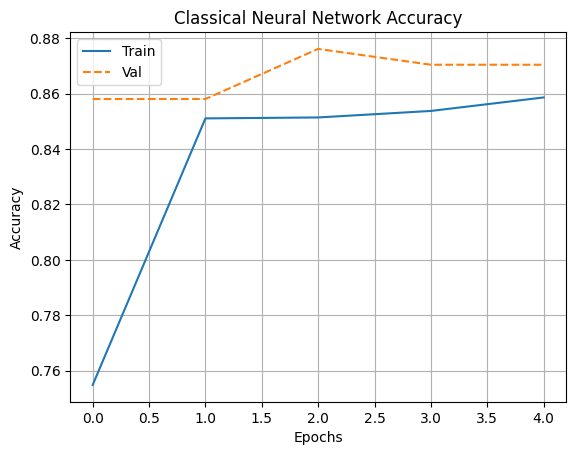

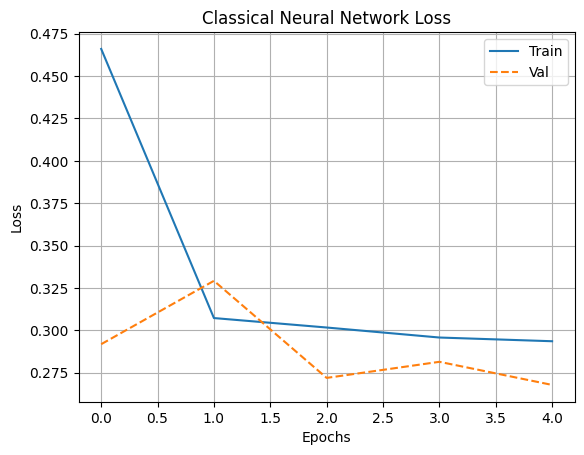

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classical Neural Network Test Accuracy: 0.8796666666666667


In [8]:
# Classical Neural Network

import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Define the classical NN
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        256,
        input_shape=(nn_phishing_x_train.shape[1],),
        activation='sigmoid'
    ),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(64, activation='sigmoid'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

nn_model.summary()

nn_optimizer = tf.keras.optimizers.Adam()

nn_model.compile(
    optimizer=nn_optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

nn_history = nn_model.fit(
    nn_phishing_x_train,
    nn_phishing_y_train,
    epochs=5,
    validation_split=0.15,
    verbose=2,
)

# Plot accuracy
plt.grid()
plt.plot(nn_history.history['accuracy'])
plt.plot(nn_history.history['val_accuracy'], '--')
plt.title('Classical Neural Network Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train', 'Val'])
plt.show()

# Plot loss
plt.grid()
plt.plot(nn_history.history['loss'])
plt.plot(nn_history.history['val_loss'], '--')
plt.title('Classical Neural Network Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train', 'Val'])
plt.show()

# Test accuracy
nn_pred_probs = nn_model.predict(nn_phishing_x_test)
nn_test_accuracy = accuracy_score(nn_phishing_y_test, nn_pred_probs.round())
print("Classical Neural Network Test Accuracy:", nn_test_accuracy)


Training Quantum Neural Network...
Epoch  1/20 - loss: 0.8737 - val_loss: 0.7404 - train_acc: 0.5358 - val_acc: 0.5267
Epoch  2/20 - loss: 0.6944 - val_loss: 0.6697 - train_acc: 0.5758 - val_acc: 0.5733
Epoch  3/20 - loss: 0.6613 - val_loss: 0.6571 - train_acc: 0.6158 - val_acc: 0.5867
Epoch  4/20 - loss: 0.6520 - val_loss: 0.6511 - train_acc: 0.6217 - val_acc: 0.6033
Epoch  5/20 - loss: 0.6454 - val_loss: 0.6438 - train_acc: 0.6392 - val_acc: 0.6400
Epoch  6/20 - loss: 0.6373 - val_loss: 0.6336 - train_acc: 0.6608 - val_acc: 0.6800
Epoch  7/20 - loss: 0.6280 - val_loss: 0.6230 - train_acc: 0.6950 - val_acc: 0.7000
Epoch  8/20 - loss: 0.6198 - val_loss: 0.6146 - train_acc: 0.7117 - val_acc: 0.7033
Epoch  9/20 - loss: 0.6138 - val_loss: 0.6087 - train_acc: 0.7233 - val_acc: 0.7133
Epoch 10/20 - loss: 0.6096 - val_loss: 0.6047 - train_acc: 0.7350 - val_acc: 0.7333
Epoch 11/20 - loss: 0.6066 - val_loss: 0.6018 - train_acc: 0.7392 - val_acc: 0.7400
Epoch 12/20 - loss: 0.6042 - val_loss: 0.

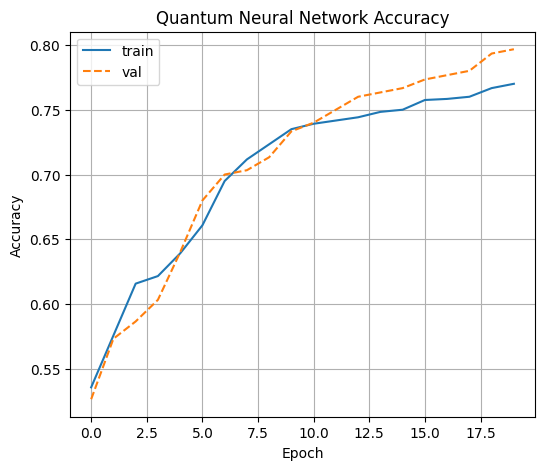

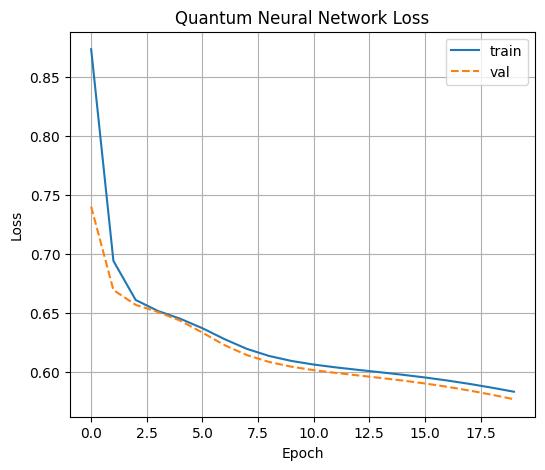

Quantum Neural Network Test Accuracy: 0.7836666666666666


In [9]:
import pennylane as qml
import pennylane.numpy as qnp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Quantum Neural Network

# Convert train/test data to PennyLane's autograd numpy
X_train_q = qnp.array(qnn_phishing_x_train, requires_grad=False)
y_train_q = qnp.array(
    qnn_phishing_y_train.values if hasattr(qnn_phishing_y_train, "values") else qnn_phishing_y_train,
    requires_grad=False
)

X_test_q = qnp.array(qnn_phishing_x_test, requires_grad=False)
y_test_q = qnp.array(
    qnn_phishing_y_test.values if hasattr(qnn_phishing_y_test, "values") else qnn_phishing_y_test,
    requires_grad=False
)

# first 1500 samples
max_qnn_train_samples = min(1500, X_train_q.shape[0])
X_train_q_small = X_train_q[:max_qnn_train_samples]
y_train_q_small = y_train_q[:max_qnn_train_samples]

# split train and validation
X_train_qnn, X_val_qnn, y_train_qnn, y_val_qnn = train_test_split(
    X_train_q_small,
    y_train_q_small,
    test_size=0.2,
    random_state=42
)

n_qubits = 6          # 6-qubit circuit
n_layers = 4          # number of entangling layers

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def qnn_circuit(x, weights):
    """
    Quantum circuit:
    - AngleEmbedding of 6 features onto 6 qubits
    - StronglyEntanglingLayers with 'weights'
    - Measure PauliZ expectation on the first qubit
    """
    qml.AngleEmbedding(x, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))  # value in [-1, 1]

def qnn_forward(X, weights):
    """
    Run the circuit on a batch of samples.
    Map outputs from [-1, 1] to [0, 1] as probabilities.
    """
    raw = [qnn_circuit(x, weights) for x in X]
    raw = qnp.array(raw)
    probs = (raw + 1.0) / 2.0     # map [-1,1] -> [0,1]
    return probs

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-7
    y_pred = qnp.clip(y_pred, eps, 1 - eps)
    return -qnp.mean(y_true * qnp.log(y_pred) + (1 - y_true) * qnp.log(1 - y_pred))

def cost(weights, X, y):
    y_pred = qnn_forward(X, weights)
    return binary_cross_entropy(y, y_pred)

# Initialize quantum weights
qnn_weights = 0.01 * qnp.random.randn(n_layers, n_qubits, 3, requires_grad=True)

opt = qml.GradientDescentOptimizer(stepsize=0.1)
n_epochs = 20
batch_size = 64

# store metrics
qnn_train_losses = []
qnn_val_losses = []
qnn_train_acc = []
qnn_val_acc = []

print("Training Quantum Neural Network...")

for epoch in range(1, n_epochs + 1):
    epoch_loss = 0.0
    batches = 0

    for start in range(0, len(X_train_qnn), batch_size):
        end = start + batch_size
        X_batch = X_train_qnn[start:end]
        y_batch = y_train_qnn[start:end]

        qnn_weights, batch_loss = opt.step_and_cost(
            lambda w: cost(w, X_batch, y_batch), qnn_weights
        )
        epoch_loss += batch_loss
        batches += 1

    epoch_loss /= batches
    qnn_train_losses.append(epoch_loss)

    # validation loss
    val_loss = cost(qnn_weights, X_val_qnn, y_val_qnn)
    qnn_val_losses.append(val_loss)

    # training accuracy
    train_probs = qnn_forward(X_train_qnn, qnn_weights)
    train_preds = (train_probs > 0.5).astype(int)
    train_acc = accuracy_score(
        np.array(y_train_qnn, dtype=int),
        np.array(train_preds, dtype=int)
    )
    qnn_train_acc.append(train_acc)

    # validation accuracy
    val_probs = qnn_forward(X_val_qnn, qnn_weights)
    val_preds = (val_probs > 0.5).astype(int)
    val_acc = accuracy_score(
        np.array(y_val_qnn, dtype=int),
        np.array(val_preds, dtype=int)
    )
    qnn_val_acc.append(val_acc)

    print(
        f"Epoch {epoch:2d}/{n_epochs} - "
        f"loss: {epoch_loss:.4f} - "
        f"val_loss: {val_loss:.4f} - "
        f"train_acc: {train_acc:.4f} - "
        f"val_acc: {val_acc:.4f}"
    )

# Plot QNN train vs validation accuracy
plt.figure(figsize=(6, 5))
plt.grid()
plt.plot(qnn_train_acc, label='train')
plt.plot(qnn_val_acc, '--', label='val')
plt.title("Quantum Neural Network Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot QNN train vs validation loss
plt.figure(figsize=(6, 5))
plt.grid()
plt.plot(qnn_train_losses, label='train')
plt.plot(qnn_val_losses, '--', label='val')
plt.title("Quantum Neural Network Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Evaluate QNN on test set
qnn_test_probs = qnn_forward(X_test_q, qnn_weights)
qnn_test_preds = (qnn_test_probs > 0.5).astype(int)

qnn_test_preds_np = np.array(qnn_test_preds, dtype=int)
qnn_test_labels_np = np.array(y_test_q, dtype=int)

quantum_accuracy = accuracy_score(qnn_test_labels_np, qnn_test_preds_np)
print("Quantum Neural Network Test Accuracy:", quantum_accuracy)

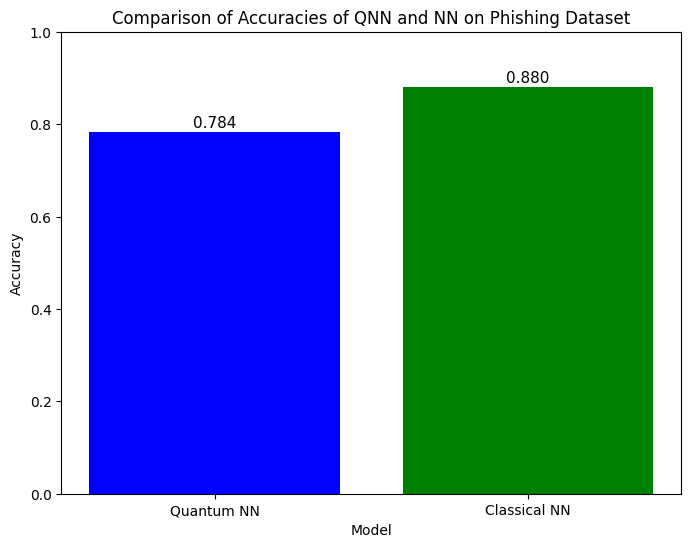

In [10]:
# Compare Classical NN and Quantum NN

# Compare Classical NN and Quantum NN

models = ['Quantum NN', 'Classical NN']
accuracies = [quantum_accuracy, nn_test_accuracy]

plt.figure(figsize=(8, 6))

bars = plt.bar(models, accuracies, color=['blue', 'green'])

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Comparison of Accuracies of QNN and NN on Phishing Dataset')
plt.ylim(0, 1)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01,
             f"{yval:.3f}", ha='center', fontsize=11)

plt.show()
